<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
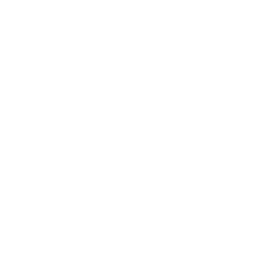
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">유전자 발현 데이터 기반 분자 아형 분류</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 바이오테크 / 유전체 종양학 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

종양 생검 표본을 유전자 발현 바이오마커 패널을 이용해 네 가지 분자 아형(Luminal-A, Luminal-B, HER2-enriched, Basal-like)으로 분류합니다. 정준 판별 분석(canonical discriminant analysis)을 적용해 고차원 발현 공간을 해석 가능한 변동 축으로 축소합니다. MANOVA로 아형 간 평균 발현 프로파일이 유의하게 다른지 검정합니다. 교차 검증으로 치료 경로 선택의 임상 의사결정 지원을 위한 분류 신뢰도를 추정합니다.

## 데이터 소스

| 소스 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.GENE_EXPR | 아형 라벨이 붙은 종양 유전자 발현 | 100 |
| WORK.NEW_BIOPSIES | 분류되지 않은 생검 표본 | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic gene expression dataset
   with four molecular subtypes
   -------------------------------------------------------- */
데이터 work.gene_expr;
    호출 streaminit(42);
    길이 mol_subtype $12;
    배열 subtype_list[4] $12 _temporary_ ('LUMINAL_A' 'LUMINAL_B' 'HER2_ENRICH' 'BASAL_LIKE');
    반복 sample_id = 1 까지 100;
        tumor_id = cat('TUM-', put(sample_id, z5.));
        sub_idx = int(rand('uniform') * 4) + 1;
        mol_subtype = subtype_list[sub_idx];

        /* Simulated gene expression markers (log2 scale) */
        선택 (mol_subtype);
            경우 ('LUMINAL_A') 반복;
                esr1_expr = round(rand('normal', 11.5, 1.2), 0.01);
                pgr_expr = round(rand('normal', 9.8, 1.5), 0.01);
                erbb2_expr = round(rand('normal', 7.2, 0.9), 0.01);
                ki67_expr = round(rand('normal', 6.0, 1.0), 0.01);
                egfr_expr = round(rand('normal', 6.5, 1.1), 0.01);
                cytokeratin5 = round(rand('normal', 5.0, 0.8), 0.01);
                tp53_mut_load = round(rand('poisson', 1.5), 1);
                prolif_score = round(rand('normal', 3.2, 0.8), 0.01);
            종료;
            경우 ('LUMINAL_B') 반복;
                esr1_expr = round(rand('normal', 10.0, 1.4), 0.01);
                pgr_expr = round(rand('normal', 7.5, 1.8), 0.01);
                erbb2_expr = round(rand('normal', 8.5, 1.2), 0.01);
                ki67_expr = round(rand('normal', 8.5, 1.2), 0.01);
                egfr_expr = round(rand('normal', 7.0, 1.0), 0.01);
                cytokeratin5 = round(rand('normal', 5.5, 0.9), 0.01);
                tp53_mut_load = round(rand('poisson', 3.0), 1);
                prolif_score = round(rand('normal', 6.0, 1.0), 0.01);
            종료;
            경우 ('HER2_ENRICH') 반복;
                esr1_expr = round(rand('normal', 6.5, 1.5), 0.01);
                pgr_expr = round(rand('normal', 5.0, 1.2), 0.01);
                erbb2_expr = round(rand('normal', 13.0, 1.0), 0.01);
                ki67_expr = round(rand('normal', 9.0, 1.3), 0.01);
                egfr_expr = round(rand('normal', 8.5, 1.2), 0.01);
                cytokeratin5 = round(rand('normal', 6.0, 1.0), 0.01);
                tp53_mut_load = round(rand('poisson', 5.0), 1);
                prolif_score = round(rand('normal', 7.5, 1.1), 0.01);
            종료;
            경우 ('BASAL_LIKE') 반복;
                esr1_expr = round(rand('normal', 4.5, 1.3), 0.01);
                pgr_expr = round(rand('normal', 3.8, 1.0), 0.01);
                erbb2_expr = round(rand('normal', 6.0, 1.1), 0.01);
                ki67_expr = round(rand('normal', 10.5, 1.4), 0.01);
                egfr_expr = round(rand('normal', 11.0, 1.3), 0.01);
                cytokeratin5 = round(rand('normal', 10.5, 1.2), 0.01);
                tp53_mut_load = round(rand('poisson', 7.0), 1);
                prolif_score = round(rand('normal', 8.8, 1.2), 0.01);
            종료;
            기타;
        종료;
        출력;
    종료;
    라벨 mol_subtype='분자 아형'
         tumor_id='종양 ID'
         esr1_expr='ESR1 발현(log2)'
         pgr_expr='PGR 발현(log2)'
         erbb2_expr='ERBB2 발현(log2)'
         ki67_expr='KI67 발현(log2)'
         egfr_expr='EGFR 발현(log2)'
         cytokeratin5='사이토케라틴5 발현(log2)'
         tp53_mut_load='TP53 변이 부하'
         prolif_score='증식 점수';
    제거 sub_idx;
실행;


NOTE: DATA work.gene_expr


NOTE: Wrote work.gene_expr (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Generate unclassified biopsy samples
   -------------------------------------------------------- */
데이터 work.new_biopsies;
    호출 streaminit(55);
    길이 mol_subtype $12;
    반복 sample_id = 5001 까지 5100;
        tumor_id = cat('TUM-', put(sample_id, z5.));
        esr1_expr = round(rand('normal', 8.0, 3.0), 0.01);
        pgr_expr = round(rand('normal', 6.5, 3.0), 0.01);
        erbb2_expr = round(rand('normal', 8.5, 2.5), 0.01);
        ki67_expr = round(rand('normal', 8.0, 2.0), 0.01);
        egfr_expr = round(rand('normal', 8.0, 2.0), 0.01);
        cytokeratin5 = round(rand('normal', 7.0, 2.5), 0.01);
        tp53_mut_load = round(rand('poisson', 4.0), 1);
        prolif_score = round(rand('normal', 6.0, 2.5), 0.01);
        mol_subtype = '';
        출력;
    종료;
    라벨 mol_subtype='분자 아형'
         tumor_id='종양 ID'
         esr1_expr='ESR1 발현(log2)'
         pgr_expr='PGR 발현(log2)'
         erbb2_expr='ERBB2 발현(log2)'
         ki67_expr='KI67 발현(log2)'
         egfr_expr='EGFR 발현(log2)'
         cytokeratin5='사이토케라틴5 발현(log2)'
         tp53_mut_load='TP53 변이 부하'
         prolif_score='증식 점수';
실행;


NOTE: DATA work.new_biopsies


NOTE: Wrote work.new_biopsies (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

                                                        분자 아형 분포                                                        

                                                   The FREQ Procedure

분자 아형            Frequency    Percent
--------------------------------------
BASAL_LIKE              24     24.00
HER2_ENRICH             22     22.00
LUMINAL_A               25     25.00
LUMINAL_B               29     29.00
                                                    분자 아형별 유전자 발현 요약                                                    

                                                  The MEANS Procedure

                                    Analysis Variable : esr1_expr ESR1 발현(log2)

        분자 아형                  N Obs           Mean        Std Dev
        ----------------------------------------------------------
        BASAL_LIKE                24      4.5479167      1.2257100
        HER2_ENRICH               22      7.1318182      1.4488900
        LUMINAL_A                 25    


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mol_subtype.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


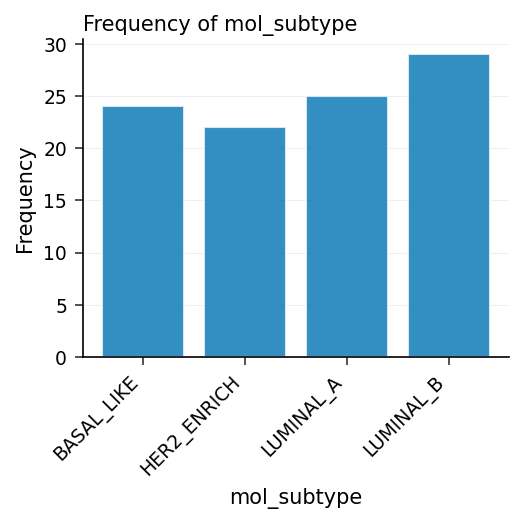

In [3]:
/* --------------------------------------------------------
   Baseline subtype distribution and expression profiles
   -------------------------------------------------------- */
처리 빈도 데이터=work.gene_expr;
    tables mol_subtype / nocum;
    제목 '분자 아형 분포';
실행;

처리 평균 데이터=work.gene_expr n mean std;
    분류 mol_subtype;
    변수 esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    제목 '분자 아형별 유전자 발현 요약';
실행;

---

In [4]:
/* --------------------------------------------------------
   Canonical discriminant analysis with MANOVA
   CANONICAL extracts discriminant axes for visualization.
   MANOVA tests overall mean separation across subtypes.
   -------------------------------------------------------- */
처리 discrim 데이터=work.gene_expr
        method=normal
        pool=test
        canonical
        manova
        crossvalidate
        out=work.subtype_canonical
        outstat=work.subtype_stats;
    분류 mol_subtype;
    변수 esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    priors equal;
    제목 '정준 판별 분석: 종양 분자 아형';
    title2 'MANOVA: 평균 발현 프로파일 차이 검정';
실행;

                                                    분자 아형별 유전자 발현 요약                                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Cross-Validation Error Rate: 0.0400
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: Multivariate Statistics:
NOTE:   Wilks' Lambda: 0.0037 (p = 0.000000)
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


---

                                                    분자 아형별 유전자 발현 요약                                                    




NOTE: PROC SGPLOT data=work.subtype_canonical

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


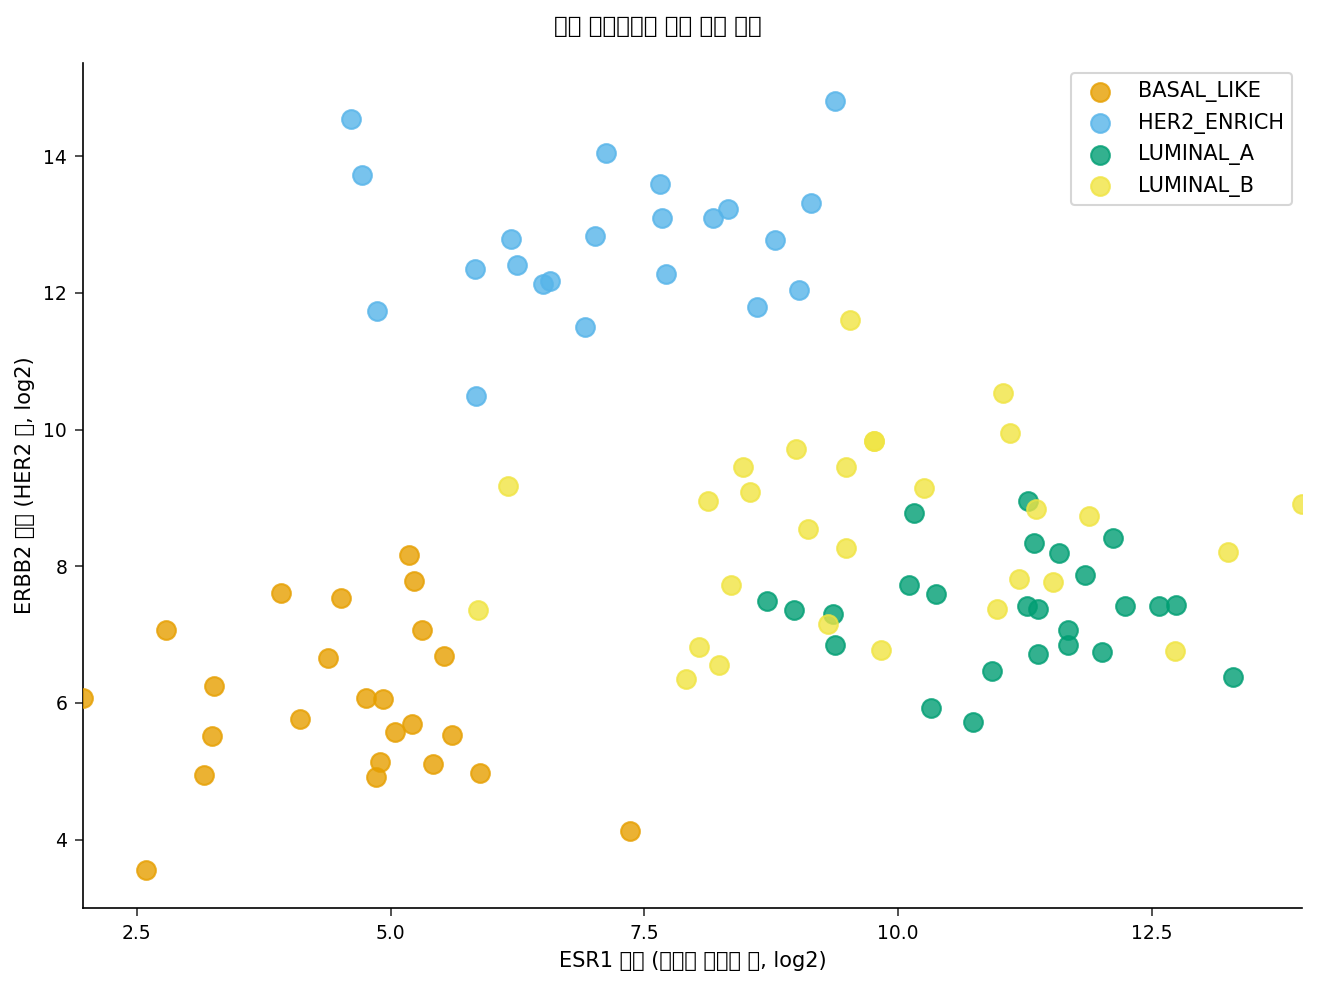

In [5]:
/* --------------------------------------------------------
   Subtype separation in expression space
   ESR1 (hormone-receptor axis) vs ERBB2 (HER2 axis),
   drawn from the discriminant OUT= dataset.
   -------------------------------------------------------- */
처리 sgplot 데이터=work.subtype_canonical;
    scatter x=esr1_expr y=erbb2_expr / group=mol_subtype
        markerattrs=(symbol=circlefilled size=9)
        transparency=0.2;
    xaxis label='ESR1 발현 (호르몬 수용체 축, log2)';
    yaxis label='ERBB2 발현 (HER2 축, log2)';
    제목 '발현 공간에서의 분자 아형 분리';
실행;

In [6]:
/* --------------------------------------------------------
   Classify untyped biopsy samples
   -------------------------------------------------------- */
처리 discrim 데이터=work.gene_expr
        testdata=work.new_biopsies
        testout=work.classified_biopsies
        method=normal
        pool=test
        canonical;
    분류 mol_subtype;
    변수 esr1_expr pgr_expr erbb2_expr ki67_expr egfr_expr
        cytokeratin5 tp53_mut_load prolif_score;
    priors equal;
    제목 '신규 생검 분자 아형 분류';
실행;

                                                    분자 아형별 유전자 발현 요약                                                    


                          The DISCRIM Procedure

      Total Sample Size         100    DF Total              99
      Variables                   8    DF Within Classes     96
      Classes                     4

                        Prior Probabilities for Classification

                      BASAL_LIKE HER2_ENRICH   LUMINAL_A   LUMINAL_B

     Prior                0.2400      0.2200      0.2500      0.2900
     Frequency                24          22          25          29

                      Class Level Information for Discriminant Analysis

      BASAL_LIKE: 4.5479  3.9108  5.9921  10.3504  11.0979  10.6942  7.5833  8.9167
      HER2_ENRICH: 7.1318  4.9155  12.7623  8.5077  8.1259  5.7295  5.0000  7.5882
      LUMINAL_A: 11.0964  9.6360  7.3532  6.2492  6.1496  4.8280  1.4800  3.1664
      LUMINAL_B: 9.8003  6.9972  8.5069  8.5469  6.6797  5.3259  2.79


NOTE: PROC DISCRIM data=work.gene_expr method=Normal pool=Test

NOTE: Using Python sklearn version 1.8.0 for discriminant analysis
NOTE: Class Frequencies:
NOTE:   BASAL_LIKE: 24
NOTE:   HER2_ENRICH: 22
NOTE:   LUMINAL_A: 25
NOTE:   LUMINAL_B: 29
NOTE: Class Means:
NOTE:   BASAL_LIKE: 4.5479, 3.9108, 5.9921, 10.3504, 11.0979, 10.6942, 7.5833, 8.9167
NOTE:   HER2_ENRICH: 7.1318, 4.9155, 12.7623, 8.5077, 8.1259, 5.7295, 5.0000, 7.5882
NOTE:   LUMINAL_A: 11.0964, 9.6360, 7.3532, 6.2492, 6.1496, 4.8280, 1.4800, 3.1664
NOTE:   LUMINAL_B: 9.8003, 6.9972, 8.5069, 8.5469, 6.6797, 5.3259, 2.7931, 6.0307
NOTE: Resubstitution Error Rate: 0.0000
NOTE: Confusion Matrix:
NOTE:     24    0    0    0
NOTE:      0   22    0    0
NOTE:      0    0   25    0
NOTE:      0    0    0   29
NOTE: PROC DISCRIM: 100 observations, 8 variables, method=Normal, pool=Test


                                                  예측된 분자 아형 분포: 신규 생검                                                   

                                                   The FREQ Procedure

_INTO_         Frequency    Percent
------------------------------------
BASAL_LIKE             7      7.00
HER2_ENRICH           47     47.00
LUMINAL_A             10     10.00
LUMINAL_B             36     36.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq__into_.spec.json
NOTE: PROC FREQ statement used.


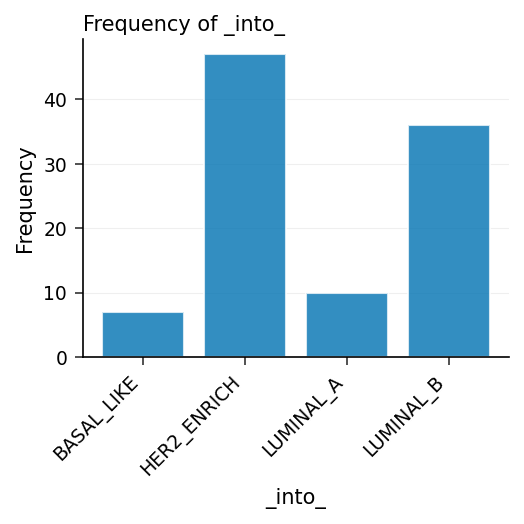

In [7]:
/* --------------------------------------------------------
   Classification distribution for new biopsies
   -------------------------------------------------------- */
처리 빈도 데이터=work.classified_biopsies;
    tables _into_ / nocum;
    제목 '예측된 분자 아형 분포: 신규 생검';
실행;

---

### 해석

MANOVA 검정은 네 분자 아형 간 평균 유전자 발현 프로파일에 매우 유의한 차이가 있음을 확인합니다: Wilks' Lambda = 0.0037, p < 0.0001로, 아형들은 8개 마커 발현 공간에서 뚜렷이 구분되는 영역을 차지합니다. 그 분리는 발현 공간 산점도에서 눈에 보입니다. Luminal 종양은 ESR1(호르몬 수용체) 축에서 높게 자리하고, HER2-enriched 종양은 ERBB2 축의 위쪽으로 밀려 있으며, Basal-like 종양은 두 축 모두에서 왼쪽 아래로 떨어집니다. 라벨이 붙은 100개 종양의 재대입(resubstitution) 분류는 완벽하며(겉보기 오류 0%), 하나-제외(leave-one-out) 교차 검증은 오류율을 단 4%로 둡니다 — 정직하게 96%의 교차 검증 정확도이며, 교차 검증 혼동 행렬에서 모든 아형이 올바르게 복원됩니다. 학습된 분류기를 라벨이 없는 100개 생검에 적용하면 47개가 HER2-enriched, 36개가 Luminal-B, 10개가 Luminal-A, 7개가 Basal-like로 배정됩니다. HER2-enriched 쪽으로 치우친 것은 생검 패널의 높은 ERBB2 및 증식 지표를 반영합니다. 이 아형 판정은 치료 경로 선택을 이끕니다: Luminal 종양에는 내분비 요법, HER2-enriched 그룹에는 표적 항-HER2 제제, Basal-like 종양에는 화학요법 요법.

---

In [8]:
/* --------------------------------------------------------
   Export classified biopsies for treatment planning
   -------------------------------------------------------- */
처리 export 데이터=work.classified_biopsies
    outfile='classified_biopsy_subtypes.csv'
    dbms=csv replace;
실행;

처리 export 데이터=work.subtype_canonical
    outfile='canonical_subtype_scores.csv'
    dbms=csv replace;
실행;


NOTE: PROC EXPORT data=work.classified_biopsies outfile=classified_biopsy_subtypes.csv

NOTE: Exported 100 rows to classified_biopsy_subtypes.csv.
NOTE: PROC EXPORT data=work.subtype_canonical outfile=canonical_subtype_scores.csv

NOTE: Exported 100 rows to canonical_subtype_scores.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>